In [1]:
import joblib 
import os 
import sys 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)


In [2]:
generated_data = joblib.load(parent_dir + f'/results/GAN_only/Oct3_all_seed_generated_data.pkl')
simulated_v_pf_data = joblib.load(parent_dir + f'/results/GAN_only/Oct3__all_seed_simulated_v_pf_data.pkl')
all_losses_seeds = joblib.load(parent_dir + f'/results/GAN_only/Oct3_all_seed_losses_data.pkl')

In [3]:
seeds = np.arange(len(generated_data.keys()))

generated_v_df = pd.DataFrame(columns=seeds)
simulated_v_pf_data_df = pd.DataFrame(columns=seeds)
all_val_g_losses_df = pd.DataFrame(columns=seeds)
all_val_d_losses_df = pd.DataFrame(columns=seeds)
all_val_d_accuracies_df = pd.DataFrame(columns=seeds)

num_buses = 42

for seed in seeds: 
    all_val_g_losses_df[seed] = all_losses_seeds[seed]['val_g_losses']
    all_val_d_losses_df[seed] = all_losses_seeds[seed]['val_d_losses']
    all_val_d_accuracies_df[seed] = all_losses_seeds[seed]['val_d_accuracies']
    try: 
        generated_v_df[seed] = generated_data[seed]['gen_v'][:num_buses]
        simulated_v_pf_data_df[seed] = simulated_v_pf_data[seed]
    except Exception as e: 
        print(e)
generated_v_df.dropna(axis='columns', inplace=True)
simulated_v_pf_data_df.dropna(axis='columns', inplace=True)

In [4]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

x = range(len(val_d_losses_mean))

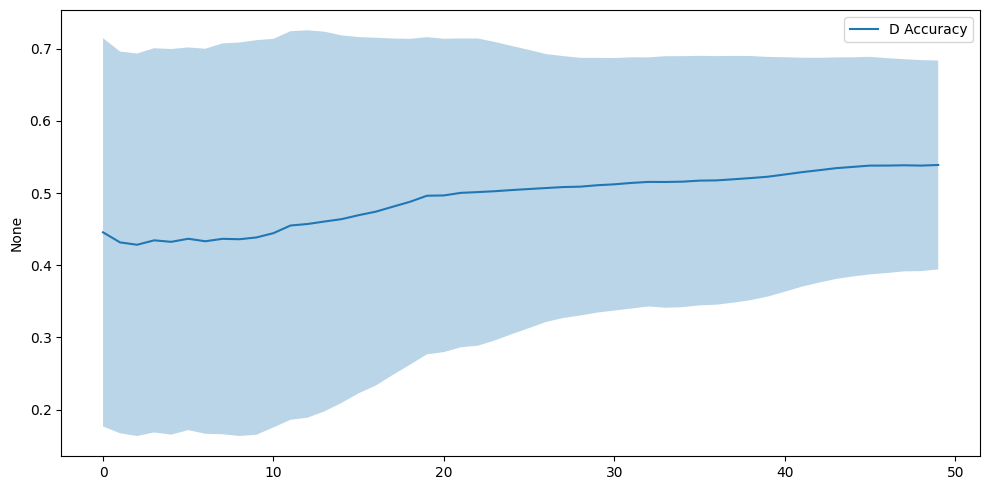

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(x=x, y=val_d_accuracies_mean, label='D Accuracy')
ax.fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)
plt.tight_layout()


### Figure: Discriminator accuracy vs. epochs 

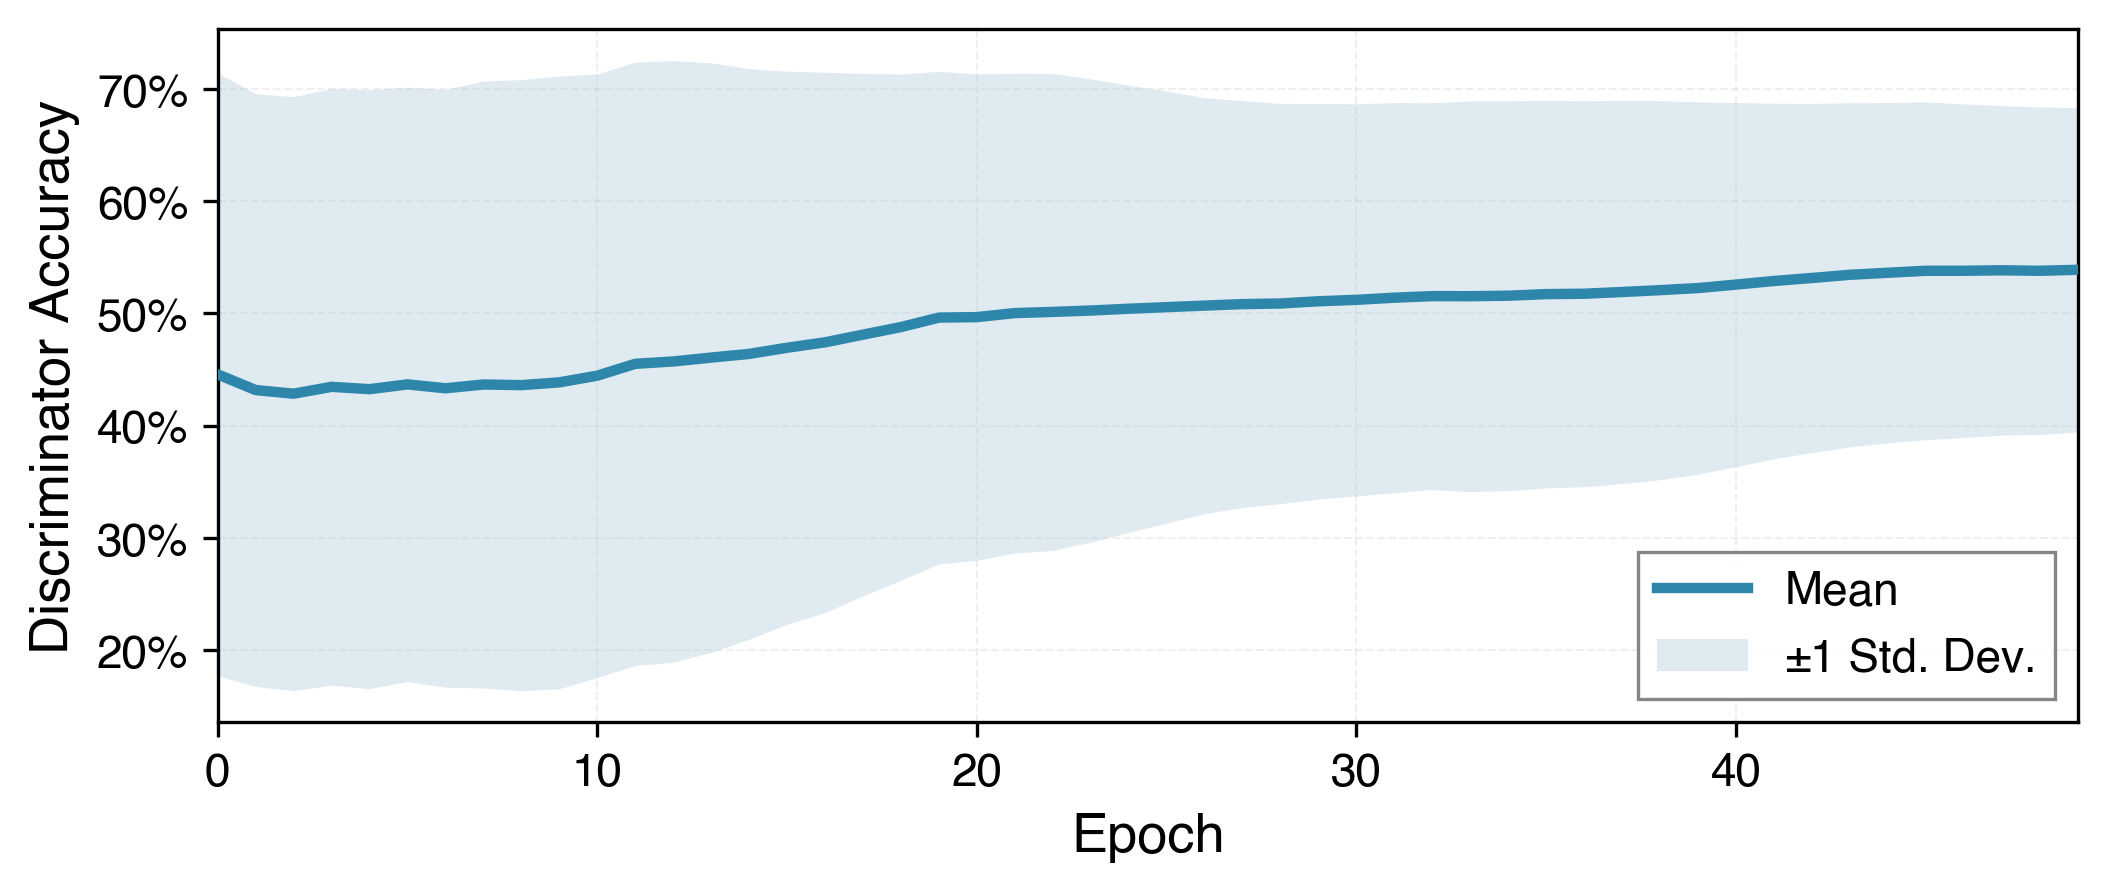

In [6]:
# Set publication-quality style with modern academic fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'  # Modern math font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 3))

# Use a sophisticated color palette
color = '#2E86AB'  # Professional blue
fill_color = '#A7C5D9'  # Lighter blue for confidence interval

# Plot with refined styling
line = ax.plot(x, val_d_accuracies_mean, 
               color=color, 
               linewidth=2.5, 
               label='Mean',
               zorder=3)

# Confidence interval with subtle transparency
ax.fill_between(x, 
                val_d_accuracies_mean - val_d_accuracies_std, 
                val_d_accuracies_mean + val_d_accuracies_std, 
                color=fill_color,
                alpha=0.35,
                linewidth=0,
                label='±1 Std. Dev.',
                zorder=2)

# Styling improvements
ax.set_xlabel('Epoch', fontweight='normal')
ax.set_ylabel('Discriminator Accuracy', fontweight='normal')
# ax.set_title('Discriminator Performance During Training', 
#              fontweight='normal', pad=15)

# Add grid for readability (subtle)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
ax.set_xlim(0,49)

# Set y-axis to percentage if needed (0-1 range)
if val_d_accuracies_mean.max() <= 1.0:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible()
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout with padding
# plt.tight_layout(pad=0.0)

# Save as high-quality PDF and PNG
plt.savefig('FIG_discriminator_accuracy.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('discriminator_accuracy.png', dpi=300, bbox_inches='tight')

plt.show()

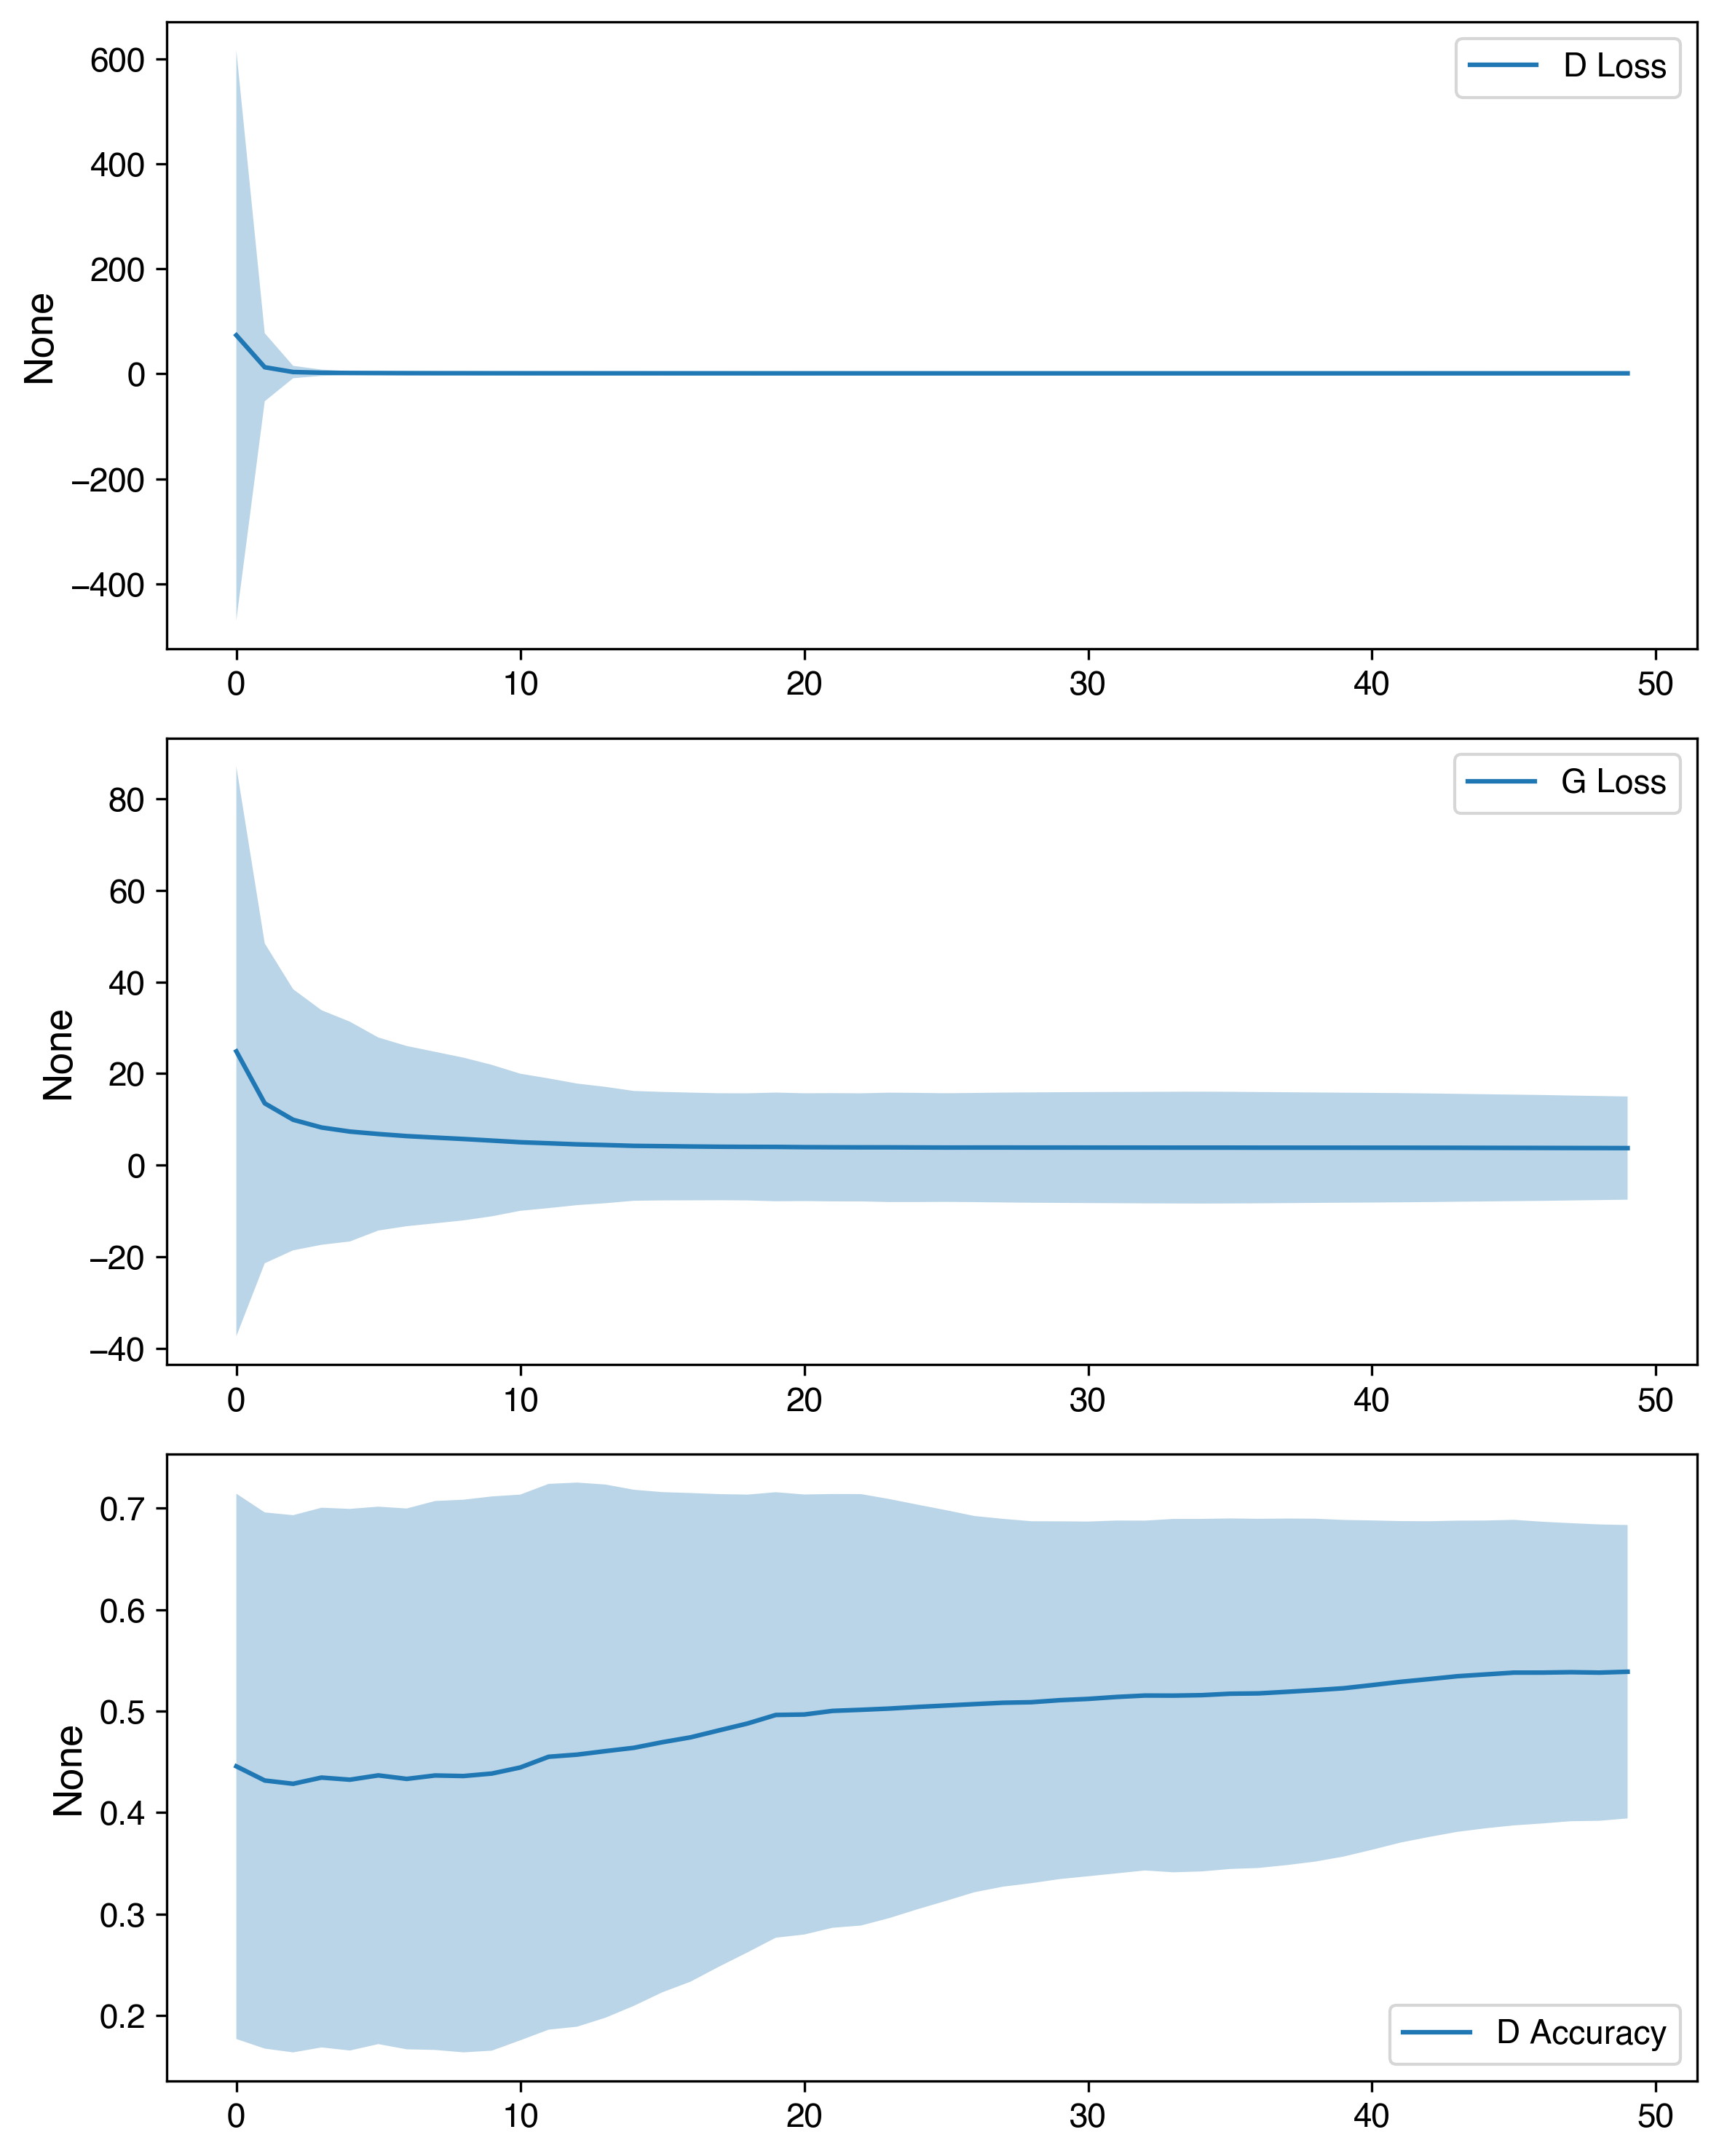

In [7]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

fig, ax = plt.subplots(3,1, figsize=(8,10))
x = range(len(val_d_losses_mean))

sns.lineplot(x=x, y=val_d_losses_mean, ax=ax[0], label='D Loss')
ax[0].fill_between(x, val_d_losses_mean - val_d_losses_std, val_d_losses_mean + val_d_losses_std, alpha=0.3)

sns.lineplot(x=x, y=val_g_losses_mean, ax=ax[1], label='G Loss')
ax[1].fill_between(x, val_g_losses_mean - val_g_losses_std, val_g_losses_mean + val_g_losses_std, alpha=0.3)

sns.lineplot(x=x, y=val_d_accuracies_mean, ax=ax[2], label='D Accuracy')
ax[2].fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Calculate mean and standard deviation for both dataframes
# simulated_mean = simulated_v_pf_data_df.mean(axis=1)
# simulated_std = simulated_v_pf_data_df.std(axis=1)
# generated_mean = generated_v_df.mean(axis=1)
# generated_std = generated_v_df.std(axis=1)

simulated_v_pf_data_df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,...,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000
1,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,...,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000
2,1.020673,1.020768,1.020710,1.020808,1.020740,1.020521,1.020393,1.020416,1.020739,1.020781,...,1.020940,1.020890,1.020337,1.020867,1.020599,1.020795,1.020569,1.021010,1.020708,1.021103
3,1.019340,1.020164,1.020501,1.020293,1.020091,1.020381,1.019226,1.019390,1.020197,1.020062,...,1.020004,1.020598,1.018779,1.020313,1.020225,1.018181,1.019587,1.020505,1.020298,1.019497
4,1.020678,1.020825,1.020728,1.020831,1.020756,1.020542,1.020381,1.020403,1.020748,1.020774,...,1.020961,1.020915,1.020350,1.020875,1.020602,1.020812,1.020582,1.021042,1.020709,1.021120
5,1.019048,1.022195,1.021349,1.021255,1.021382,1.020935,1.017771,1.019499,1.020599,1.019699,...,1.021065,1.022003,1.021015,1.020488,1.020502,1.020624,1.020910,1.021969,1.020621,1.020812
6,1.019393,1.021567,1.021213,1.020904,1.020965,1.020904,1.017927,1.019519,1.020402,1.019929,...,1.020593,1.021525,1.019609,1.020473,1.020363,1.019387,1.020810,1.021541,1.020447,1.020220
7,1.020901,1.020810,1.020827,1.020687,1.021247,1.020227,1.020595,1.020638,1.021020,1.021124,...,1.020972,1.021257,1.020246,1.021138,1.020794,1.021428,1.020489,1.021280,1.020716,1.021381
8,1.021733,1.020665,1.020786,1.020598,1.023291,1.019647,1.020605,1.021911,1.021694,1.022160,...,1.021204,1.021585,1.020287,1.021668,1.021511,1.022179,1.020949,1.021586,1.020756,1.021765
9,1.022072,1.020494,1.020651,1.020608,1.024077,1.019356,1.020663,1.022315,1.021650,1.022350,...,1.021317,1.021700,1.020521,1.021986,1.021671,1.022660,1.021122,1.021760,1.020610,1.021773


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mean and standard deviation for both dataframes
fin_tol = 1e-12
tol = 1e-12
simulated_mean = simulated_v_pf_data_df.mean(axis=1)
simulated_std = simulated_v_pf_data_df.std(axis=1)
# simulated_std.where(simulated_std > tol, fin_tol, inplace=True)

generated_mean = generated_v_df.mean(axis=1)
generated_std = generated_v_df.std(axis=1)
# generated_std.where(generated_std > tol, fin_tol, inplace=True)

simulated_mean = np.asarray(simulated_mean, dtype=float)
simulated_std = np.asarray(simulated_std, dtype=float)

generated_mean = np.asarray(generated_mean, dtype=float)
generated_std = np.asarray(generated_std, dtype=float)

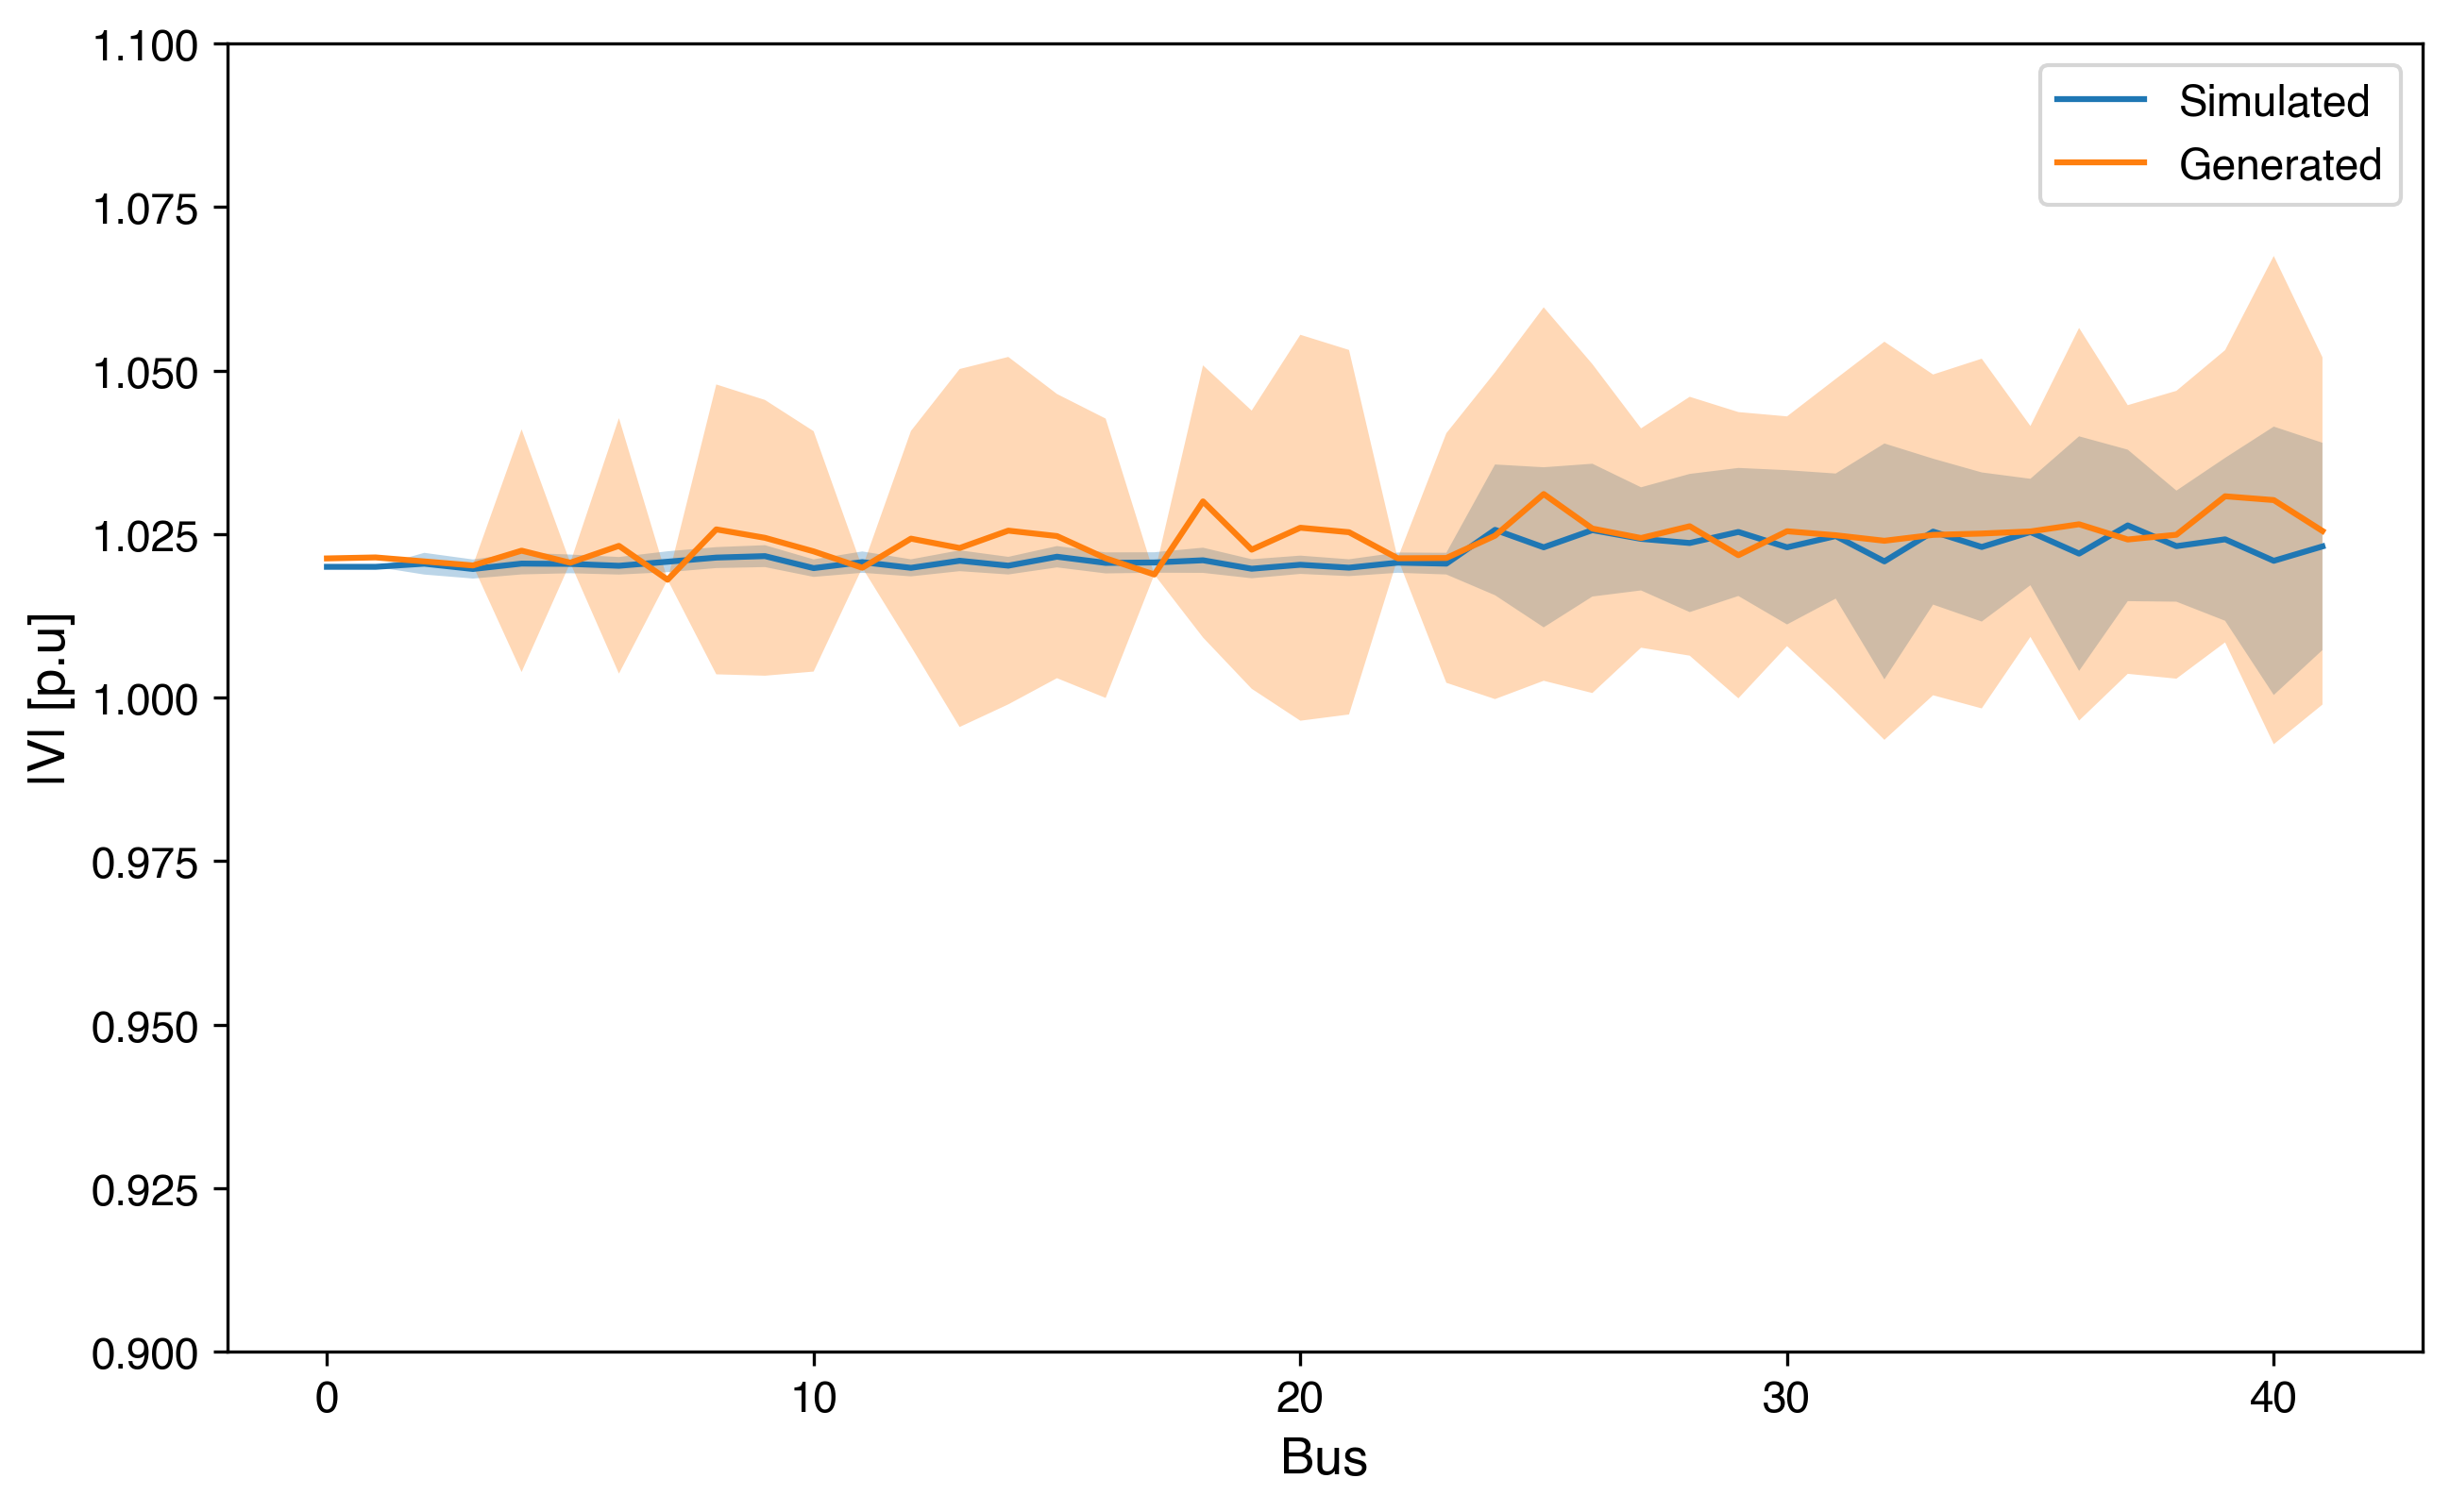

In [10]:
# Create the plot
plt.figure(figsize=(10, 6))
x = range(len(simulated_mean))
sns.lineplot(x=x, y=simulated_mean, label='Simulated')
plt.fill_between(x, simulated_mean - simulated_std, simulated_mean + simulated_std, alpha=0.3)
sns.lineplot(x=x, y=generated_mean, label='Generated')
plt.fill_between(x, generated_mean - generated_std, generated_mean + generated_std, alpha=0.3)          
plt.ylim(0.9,1.1)       
plt.xlabel('Bus')
plt.ylabel('|V| [p.u]')
plt.legend()
plt.show()

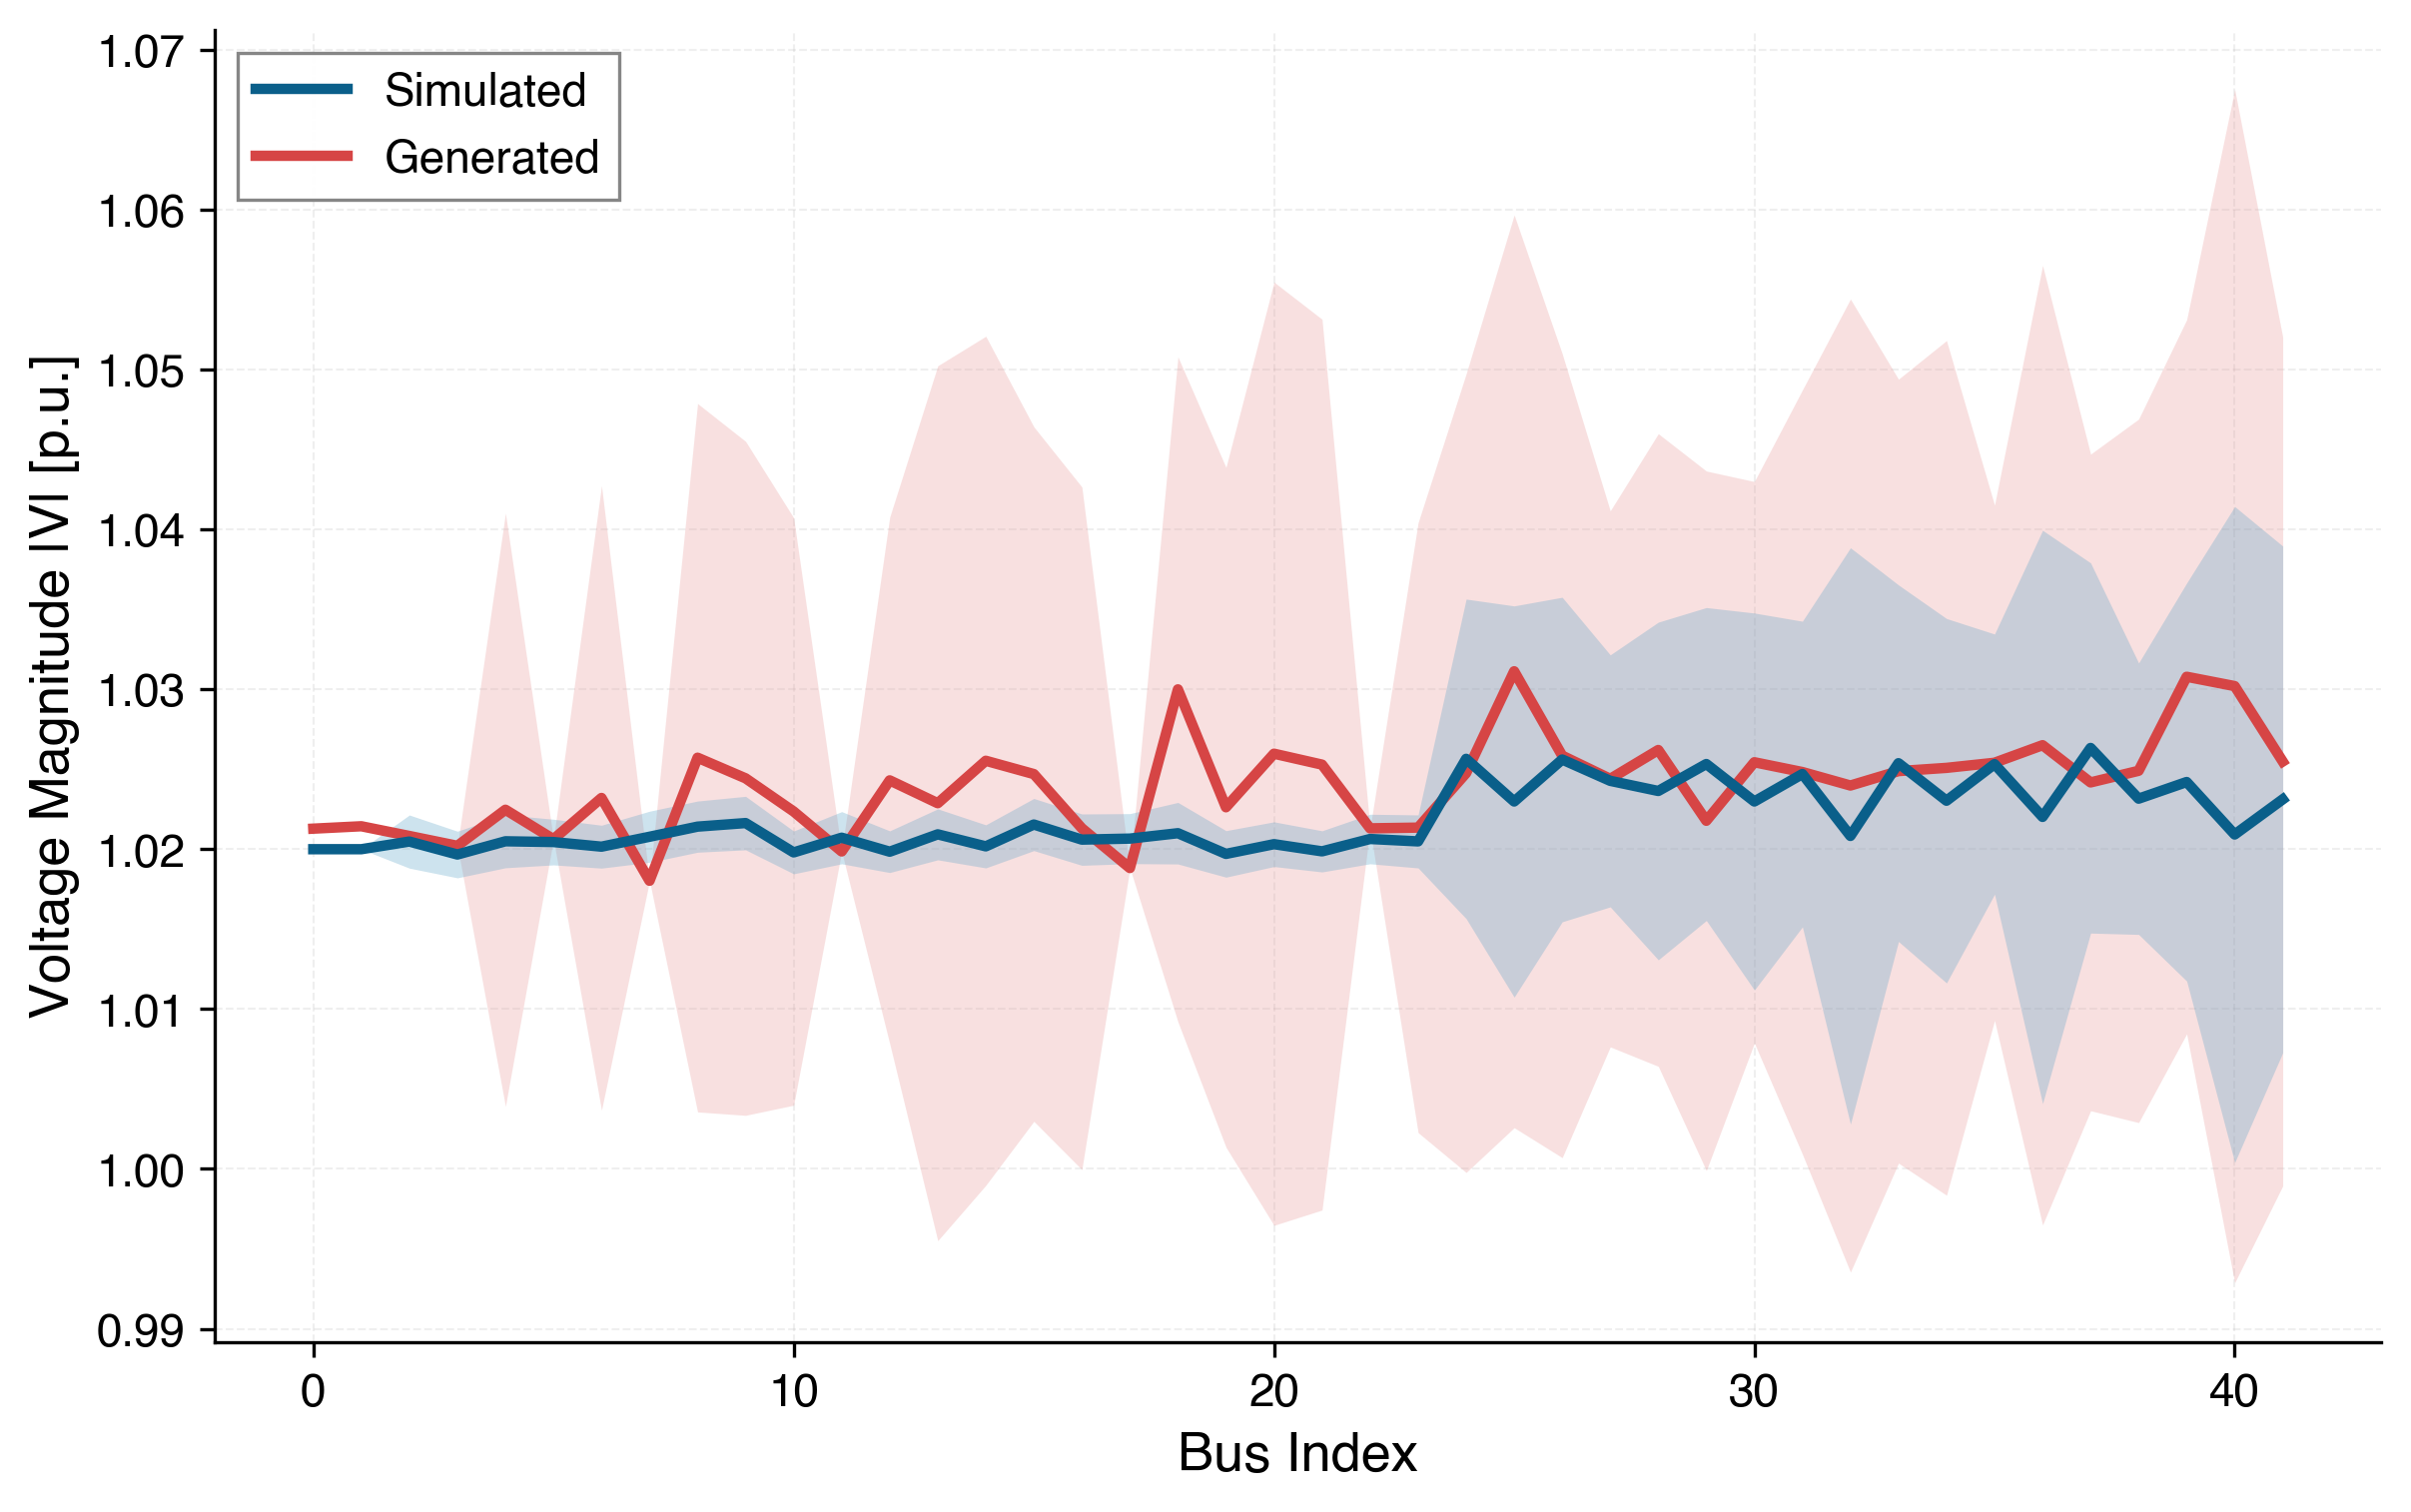

In [11]:
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 5))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = range(len(simulated_mean))

# Plot simulated data
ax.plot(x, simulated_mean, 
        color=color_simulated, 
        linewidth=2.5, 
        label='Simulated',
        zorder=4)
ax.fill_between(x, 
                simulated_mean - simulated_std, 
                simulated_mean + simulated_std, 
                color=fill_sim,
                alpha=0.3,
                linewidth=0,
                zorder=2)

# Plot generated data
ax.plot(x, generated_mean, 
        color=color_generated, 
        linewidth=2.5, 
        label='Generated',
        zorder=3)
ax.fill_between(x, 
                generated_mean - generated_std, 
                generated_mean + generated_std, 
                color=fill_gen,
                alpha=0.3,
                linewidth=0,
                zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude |V| [p.u.]', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
        #      fontweight='semibold', pad=15)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# # Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

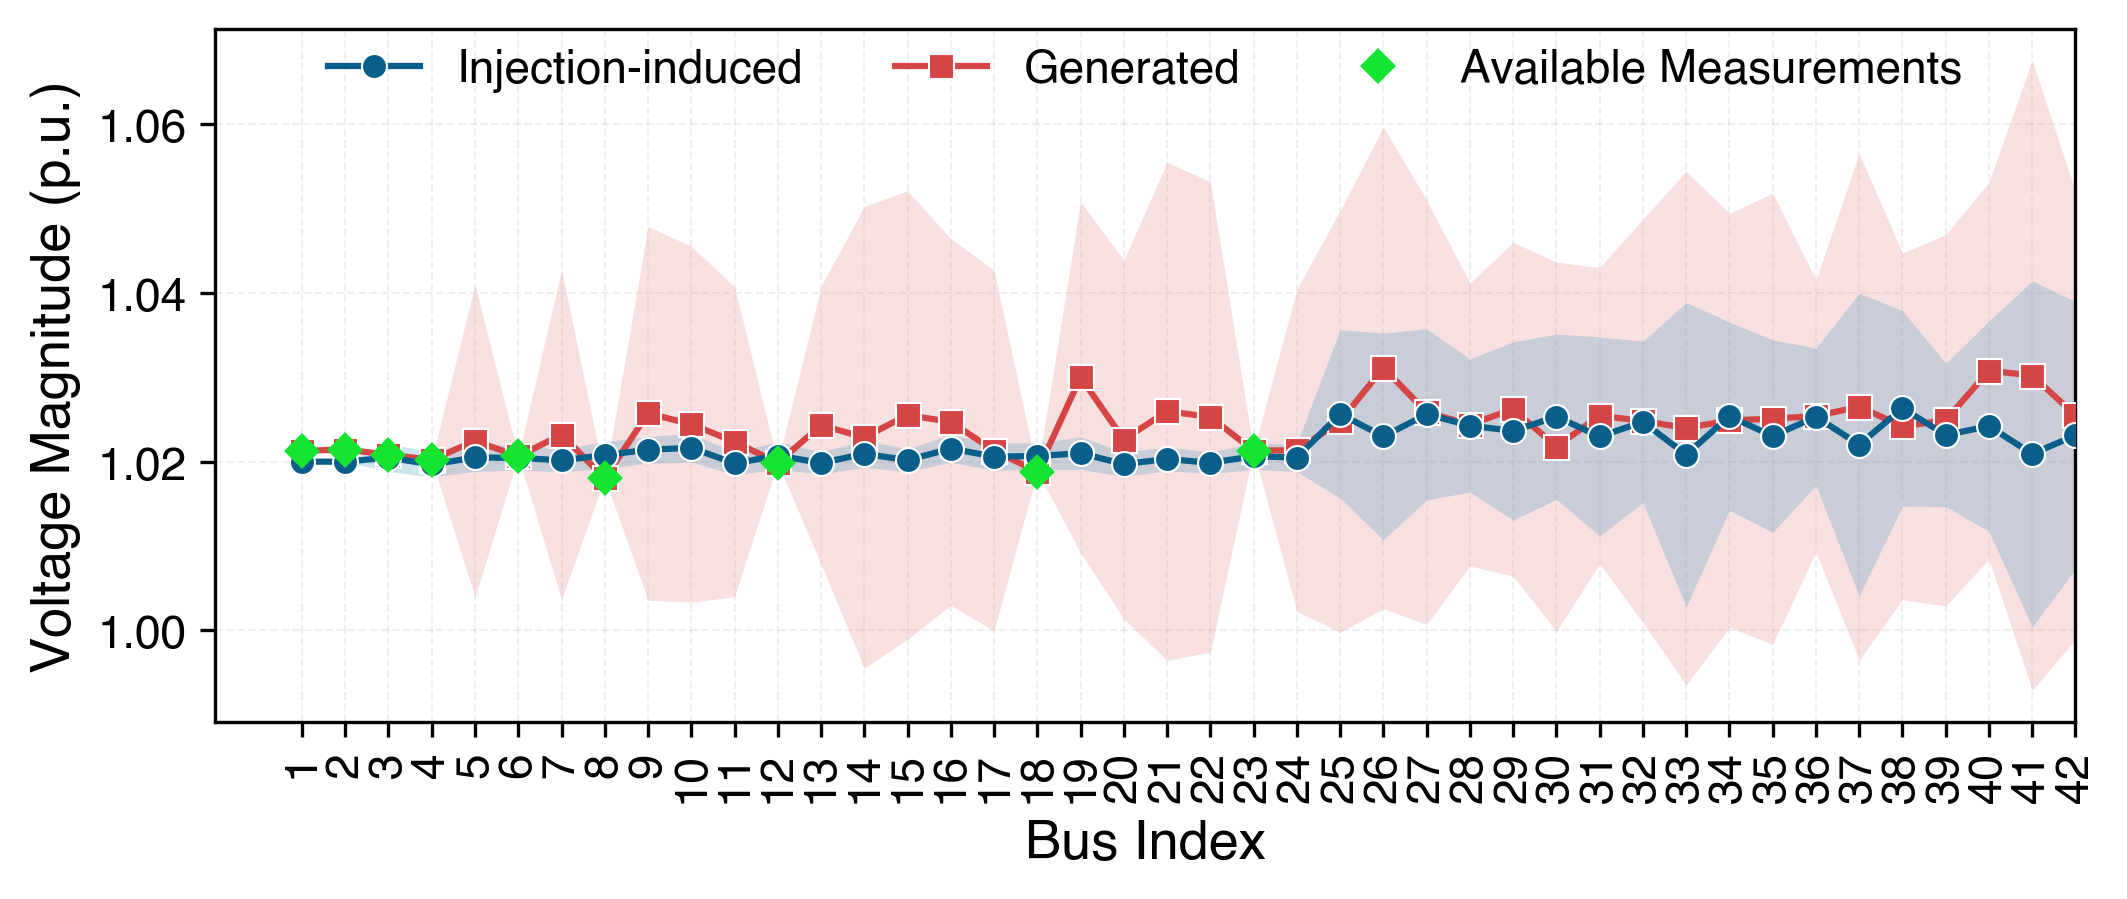

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 3))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
color_meas = "#15E431"
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = np.arange(len(simulated_mean)) + 1

# Plot simulated data (markers only)
ax.plot(x, simulated_mean, 
        color=color_simulated, 
        marker='o',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Injection-induced',
        zorder=4)
ax.fill_between(x, 
                simulated_mean - simulated_std, 
                simulated_mean + simulated_std, 
                color=fill_sim,
                alpha=0.3,
                linewidth=0,
                zorder=2)

# Plot generated data (markers only)
ax.plot(x, generated_mean, 
        color=color_generated, 
        marker='s',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Generated',
        zorder=3)
ax.fill_between(x, 
                generated_mean - generated_std, 
                generated_mean + generated_std, 
                color=fill_gen,
                alpha=0.3,
                linewidth=0,
                zorder=1)

x_at_meas = np.array([0,1,2,3,5,7,11,17,22]) + 1

# overlay special markers at x_at_meas
mask = np.isin(x, x_at_meas)   # find which x values are in x_at_meas
ax.plot(
    x[mask], generated_mean[mask], 
    marker='D',               # change this to any marker ('^', '*', 'D', etc.)
    markersize=5,
    linestyle='None',
    markeredgewidth=1,
    markeredgecolor=color_meas,
    color=color_meas,
    zorder=4,
    label='Available Measurements'
)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude (p.u.)', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
#              fontweight='semibold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(-1,42)

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
# legend = ax.legend(frameon=True, 
#                    loc='best',
#                    framealpha=0.95,
#                    edgecolor='gray',
#                    fancybox=False,
#                    shadow=False)
plt.legend(
    loc='lower center',     # place legend above the plot
    bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
    ncol=3,                 # number of columns (adjust depending on how many labels you have)
    frameon=False           # optional: remove legend box frame
)
# legend.get_frame().set_linewidth(0.8)

# Tight layout
# plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
np.mean((simulated_mean - generated_mean)**2)

-0.0021311024906108932


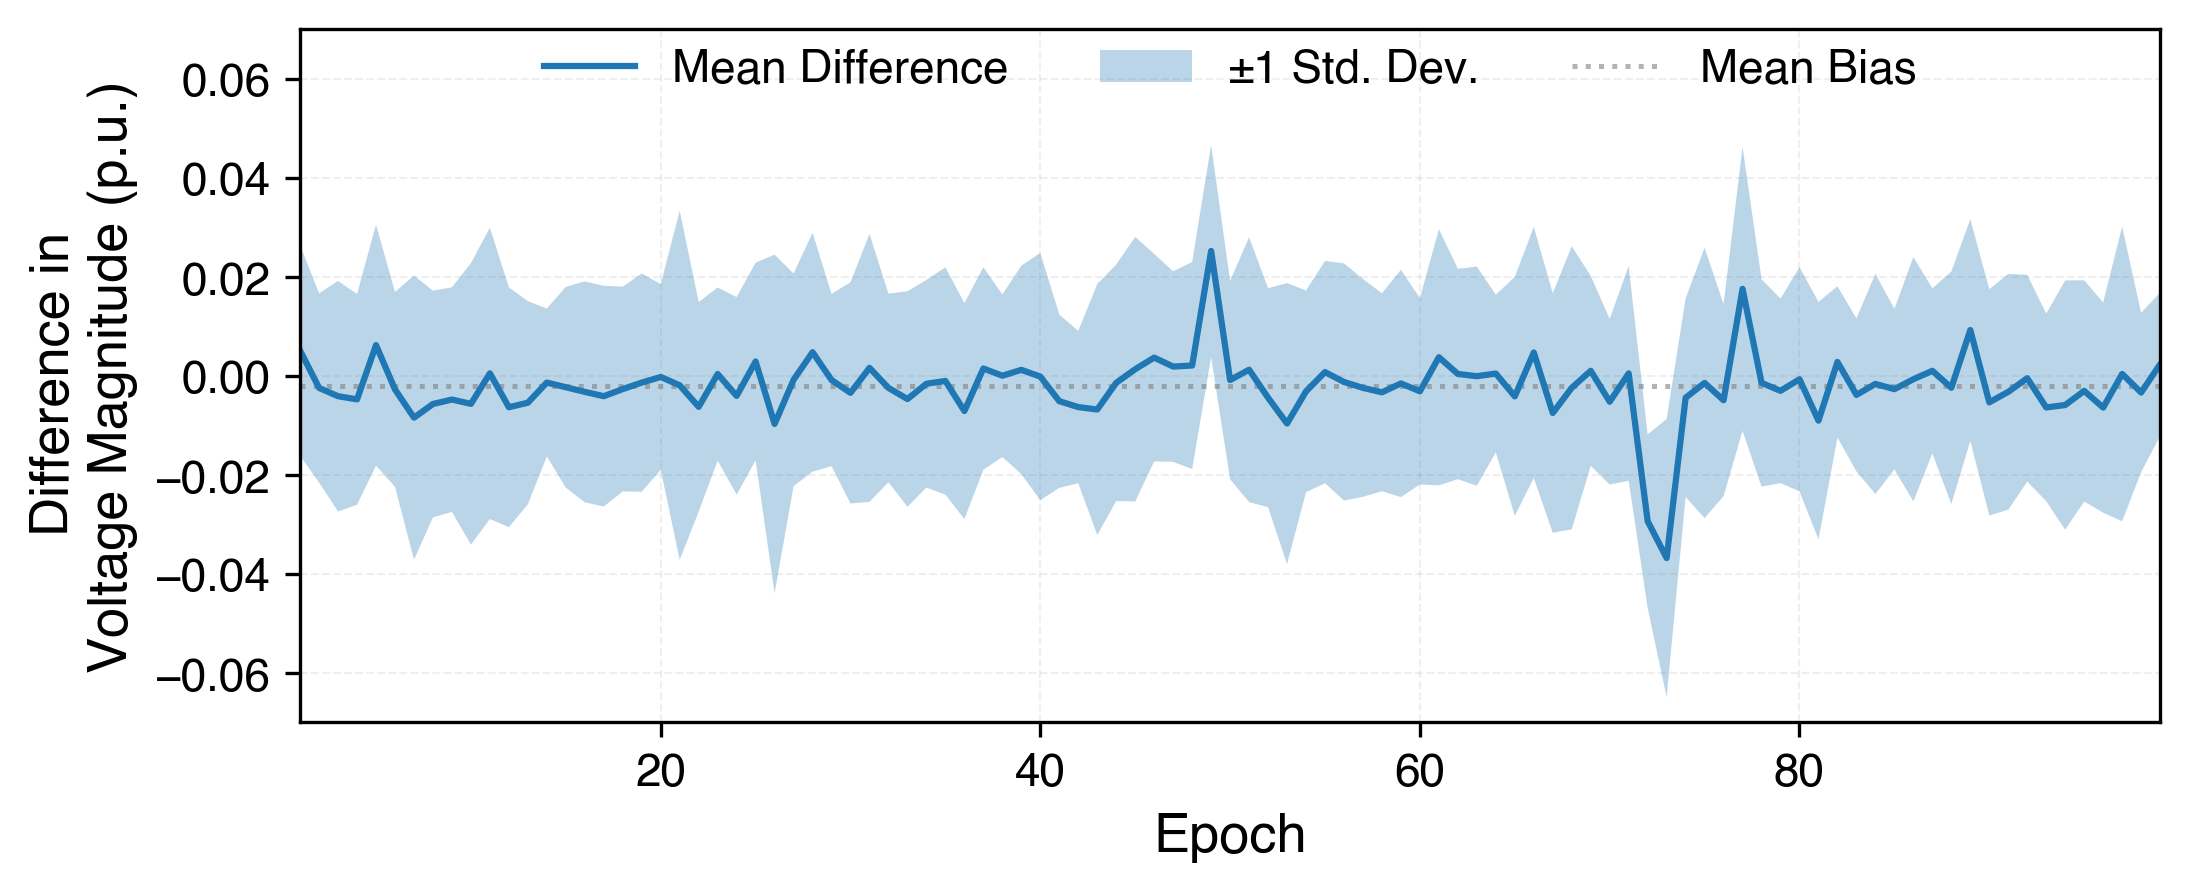

In [ ]:
diff_sim_gen_df = simulated_v_pf_data_df - generated_v_df
diff_sim_gen_mean = diff_sim_gen_df.mean(axis=0)
diff_sim_gen_std = diff_sim_gen_df.std(axis=0)
diff_sim_gen_mean = np.asarray(diff_sim_gen_mean, dtype=float)
diff_sim_gen_std = np.asarray(diff_sim_gen_std, dtype=float)

mean_diff_mean = diff_sim_gen_mean.mean()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'  # Modern math font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'



# Create the plot 
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(diff_sim_gen_mean)) + 1
sns.lineplot(x=x, y=diff_sim_gen_mean, label='Mean Difference')
plt.fill_between(x, diff_sim_gen_mean - diff_sim_gen_std, diff_sim_gen_mean + diff_sim_gen_std, alpha=0.3, label='±1 Std. Dev.')
plt.xlabel('Epoch')
plt.ylabel('Difference in \nVoltage Magnitude (p.u.)')

# Add grid for readability (subtle)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)

ax.axhline(y=mean_diff_mean, color='gray', linestyle=':', linewidth=1.2, 
           alpha=0.6, zorder=1, label='Mean Bias')

# Add the bias value as a tick on the y-axis
# yticks = list(ax.get_yticks())
# yticks.append(mean_diff_mean)  # add bias value
# ax.set_yticks(yticks)

# # Format so it shows the number (e.g., 0.1234)
# ax.set_yticklabels([f"{yt:.4f}" for yt in yticks])
ax.set_ylim(-0.07,0.07)
ax.set_axisbelow(True)
ax.set_xlim(1,99)

plt.legend(
    loc='lower center',     # place legend above the plot
    bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
    ncol=3,                 # number of columns (adjust depending on how many labels you have)
    frameon=False           # optional: remove legend box frame
)
print(mean_diff_mean)

plt.savefig('FIG_simulated_v_generated_mean.pdf', dpi=300, bbox_inches='tight')

plt.show()

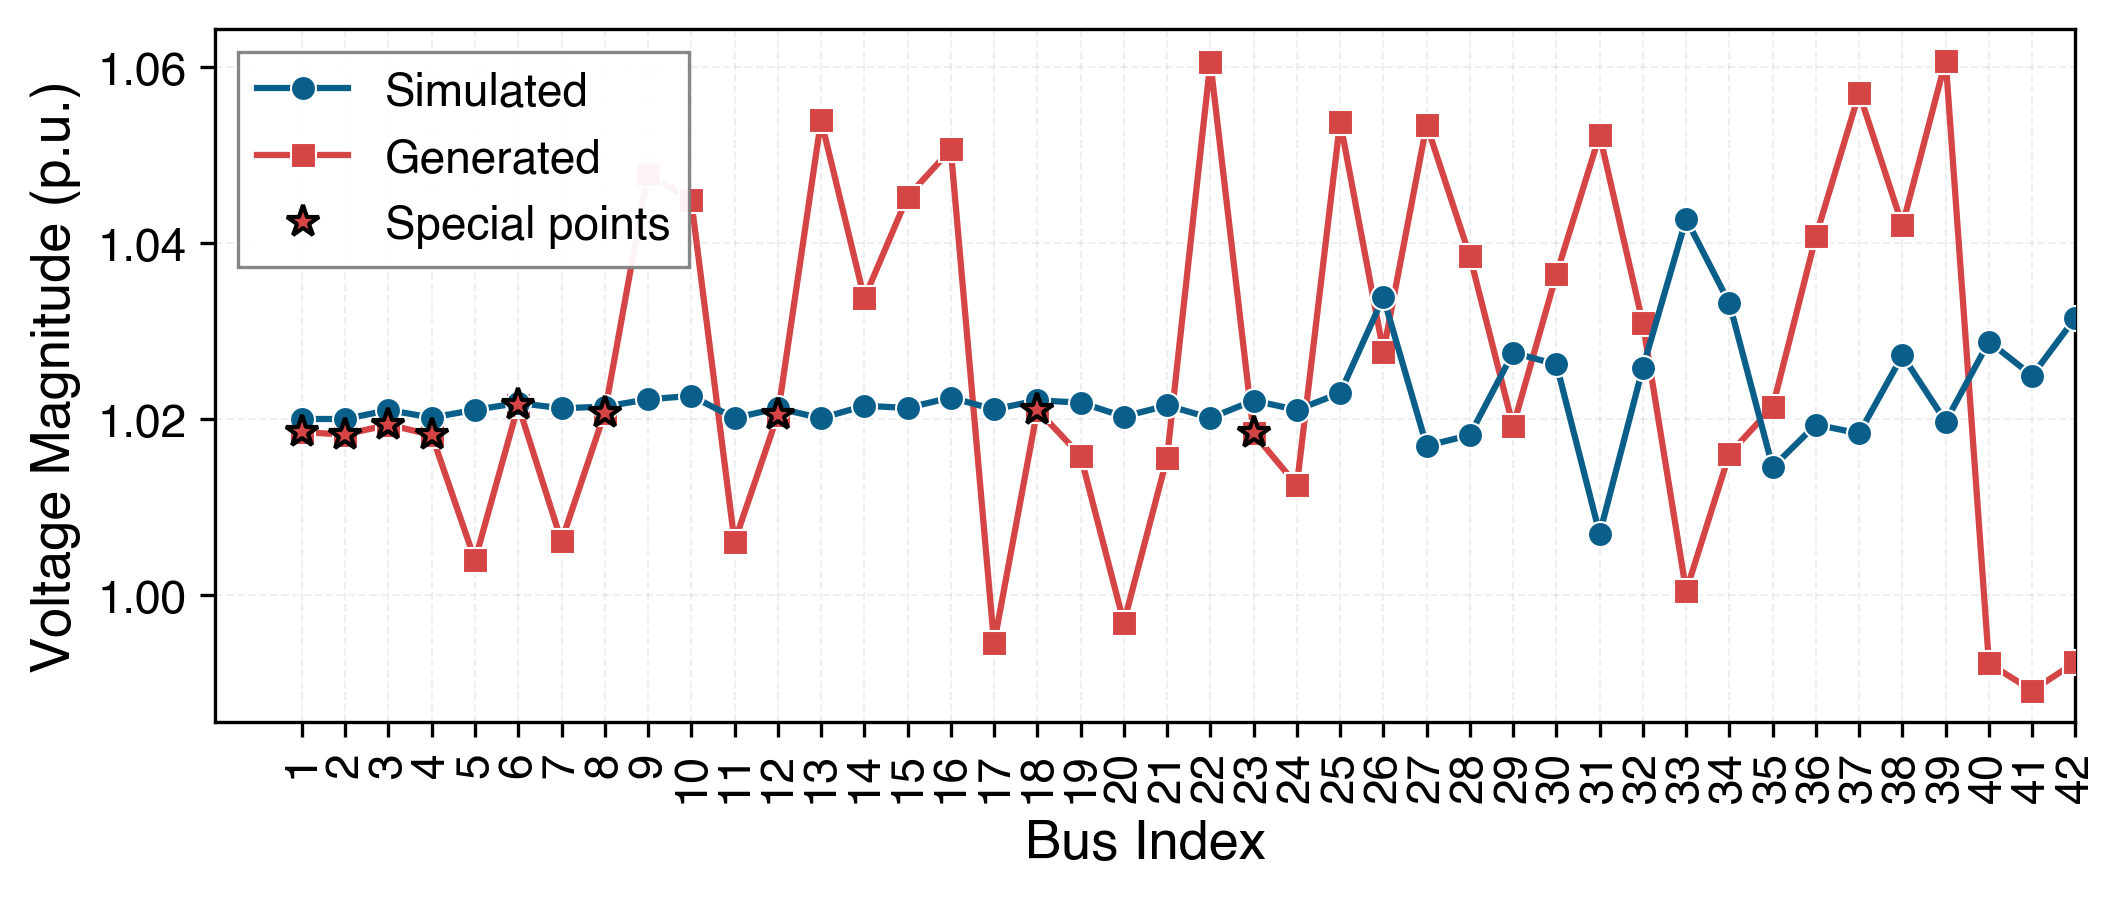

In [14]:

import numpy as np

sim_v = np.array([1.02      , 1.02      , 1.02100795, 1.02016145, 1.02103544,
       1.02181593, 1.02122003, 1.02140399, 1.02223644, 1.02262013,
       1.02011305, 1.02122341, 1.02009306, 1.02149374, 1.02126282,
       1.02243604, 1.02108595, 1.02211313, 1.02186574, 1.02027054,
       1.02153977, 1.02011215, 1.0220965 , 1.021033  , 1.02293678,
       1.03382348, 1.01695448, 1.0181725 , 1.02753385, 1.02620702,
       1.00697175, 1.02583592, 1.04270981, 1.03313046, 1.01452208,
       1.01936316, 1.01836013, 1.02721613, 1.01970819, 1.02878812,
       1.02492277, 1.03151824])

gen_v = np.array([1.0185064 , 1.0182332 , 1.0193564 , 1.0181855 , 1.0039685 ,
       1.0215545 , 1.0061138 , 1.0207276 , 1.0478702 , 1.0448189 ,
       1.0060495 , 1.0204618 , 1.0539194 , 1.0337081 , 1.0452377 ,
       1.0506068 , 0.9945173 , 1.0210296 , 1.0158246 , 0.9968764 ,
       1.0156115 , 1.0605401 , 1.0183688 , 1.012476  , 1.0537732 ,
       1.0276397 , 1.0534039 , 1.0384878 , 1.0191611 , 1.0364166 ,
       1.0522456 , 1.0308548 , 1.000465  , 1.0160466 , 1.0213704 ,
       1.040762  , 1.0570031 , 1.041991  , 1.0607047 , 0.99223906,
       0.98916256, 0.9923778 ])

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 3))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = np.arange(len(sim_v)) + 1

# Plot simulated data (markers only)
ax.plot(x, sim_v, 
        color=color_simulated, 
        marker='o',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Simulated',
        zorder=4)
# ax.fill_between(x, 
#                 simulated_mean - simulated_std, 
#                 simulated_mean + simulated_std, 
#                 color=fill_sim,
#                 alpha=0.3,
#                 linewidth=0,
#                 zorder=2)

# Plot generated data (markers only)
ax.plot(x, gen_v, 
        color=color_generated, 
        marker='s',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Generated',
        zorder=3)

x_at_meas = np.array([0,1,2,3,5,7,11,17,22]) + 1

# overlay special markers at x_at_meas
mask = np.isin(x, x_at_meas)   # find which x values are in x_at_meas
ax.plot(
    x[mask], gen_v[mask], 
    marker='*',               # change this to any marker ('^', '*', 'D', etc.)
    markersize=8,
    linestyle='None',
    markeredgewidth=1,
    markeredgecolor='black',
    color=color_generated,
    zorder=4,
    label='Special points'
)


# ax.fill_between(x, 
#                 generated_mean - generated_std, 
#                 generated_mean + generated_std, 
#                 color=fill_gen,
#                 alpha=0.3,
#                 linewidth=0,
#                 zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude (p.u.)', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
#              fontweight='semibold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(-1,42)

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
# plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

## TapSEGNN figure 

In [6]:
import os 
import sys 
import torch
import time
from datetime import datetime
import random 
import numpy as np 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)


from src.dataset.custom_dataset import NodeEdgeTapDatasetV2, GenDataset, DiscDataset
from src.model.graph_model import NEGATGenerator, DiffPoolDiscriminator
from training.trainer import trainer, train_GAN
from utils.model_utils import initialize_model, get_eval_results, impute_dataset_with_model_G
from utils.gen_utils import dataset_splitter, get_device, load_config, generate_markdown_report_and_save_model, generate_markdown_report_GAN_and_save_model
from utils.ppnet_utils import initialize_network
from utils.load_data_utils import load_sampled_input_data

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

config_tapsegnn = load_config('config.yaml')
device = get_device(config_tapsegnn['device'])

net = initialize_network(net_name=config_tapsegnn['data']['net_name'],
                         load_std=config_tapsegnn['data']['load_std'])

sampled_input_data = load_sampled_input_data(sc_type=config_tapsegnn['data']['scenario_type'], 
                                                   net=net, 
                                                   num_samples=config_tapsegnn['data']['num_samples'], 
                                                   noise=config_tapsegnn['data']['noise'])

dataset = NodeEdgeTapDatasetV2(model_name=config_tapsegnn['model']['name'], 
                                sampled_input_data=sampled_input_data)

all_loaders, plot_loader = dataset_splitter(dataset,
                                    batch_size=config_tapsegnn['loader']['batch_size'], 
                                    split_list=config_tapsegnn['loader']['split_list'])

model = initialize_model(model_name=config_tapsegnn['model']['name'],
                        dataset=dataset,
                        node_out_features=config_tapsegnn['model']['node_out_features'],
                        list_node_hidden_features=config_tapsegnn['model']['list_node_hidden_features'],
                        k_hop_node=config_tapsegnn['model']['k_hop_node'],
                        edge_out_features=config_tapsegnn['model']['edge_out_features'], 
                        list_edge_hidden_features=config_tapsegnn['model']['list_edge_hidden_features'],
                        k_hop_edge=config_tapsegnn['model']['k_hop_edge'],
                        trafo_hop=config_tapsegnn['model']['trafo_hop'],
                        edge_index_list=sampled_input_data['edge_index'],
                        gat_out_features=config_tapsegnn['model']['gat_out_features'],
                        gat_head=config_tapsegnn['model']['gat_head'],
                        bias=config_tapsegnn['model']['bias'], 
                        normalize=config_tapsegnn['model']['normalize'], 
                        device=device,
                        ).to(device)

checkpoint = torch.load(parent_dir + "/results/TapSEGNN copy.pth")
model.load_state_dict(checkpoint)


Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 

Selecting all the MV/LV transformers in the network 


 Embedding real measurement locations for Net-A

Scaling inputs...
Number of V, P measurements 18 out of 84

Number of P_to, Q_to, P_from, Q_from measurements 12 out of 42

Sparsity of PV measurements at buses = 0.2%
Sparsity of P+ measurements at branches = 0.3
Dataset for MultiTapSEGNN selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...

All transformers have same number of taps, using shared parameter \omega.


<All keys matched successfully>

In [14]:
results, pred_se_va, label_se_va = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config_tapsegnn['training']['loss_tap_weight'], 
                                trained_model=model, 
                                scaler=sampled_input_data['scaler_y_label'], 
                                output_pred_va=True)

# remove offset 
pred_se_va = pred_se_va - 10.0
label_se_va = label_se_va - 10.0 

pred_se_va.shape, label_se_va.shape

Calculating results for StandardScaled Voltage and Angles.


(torch.Size([2688, 2]), torch.Size([2688, 2]))

In [15]:
pred_se_va[:42,0]

tensor([1.0196, 1.0213, 1.0212, 1.0191, 1.0216, 1.0208, 1.0198, 1.0209, 1.0196,
        1.0188, 1.0192, 1.0213, 1.0202, 1.0203, 1.0198, 1.0192, 1.0201, 1.0203,
        1.0202, 1.0202, 1.0202, 1.0210, 1.0201, 1.0206, 1.0747, 1.0203, 1.0204,
        1.0400, 1.0201, 0.9953, 1.0452, 1.0728, 1.0752, 1.0473, 1.0120, 0.9972,
        1.0745, 1.0724, 1.0448, 1.0779, 0.9958, 1.0764])

In [16]:
pred_se_va_rs = torch.reshape(pred_se_va, (64,42,-1))
label_se_va_rs = torch.reshape(label_se_va, (64,42,-1))

error_pl = (pred_se_va_rs - label_se_va_rs)
error_v = error_pl[:,:,0].T 
error_a = error_pl[:,:,1].T

error_v = error_v ** 2
error_a = error_a ** 2 

mean_error_v = error_v.mean(dim=1)
rmse_v = torch.sqrt(mean_error_v)

mean_error_a = error_a.mean(dim=1)
rmse_a = torch.sqrt(mean_error_a)


In [19]:
rmse_v

tensor([0.0006, 0.0008, 0.0009, 0.0009, 0.0007, 0.0009, 0.0004, 0.0005, 0.0004,
        0.0006, 0.0007, 0.0009, 0.0004, 0.0003, 0.0004, 0.0004, 0.0002, 0.0004,
        0.0006, 0.0004, 0.0004, 0.0007, 0.0004, 0.0001, 0.0027, 0.0011, 0.0021,
        0.0036, 0.0014, 0.0006, 0.0019, 0.0010, 0.0010, 0.0014, 0.0024, 0.0013,
        0.0006, 0.0019, 0.0010, 0.0029, 0.0012, 0.0021])

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


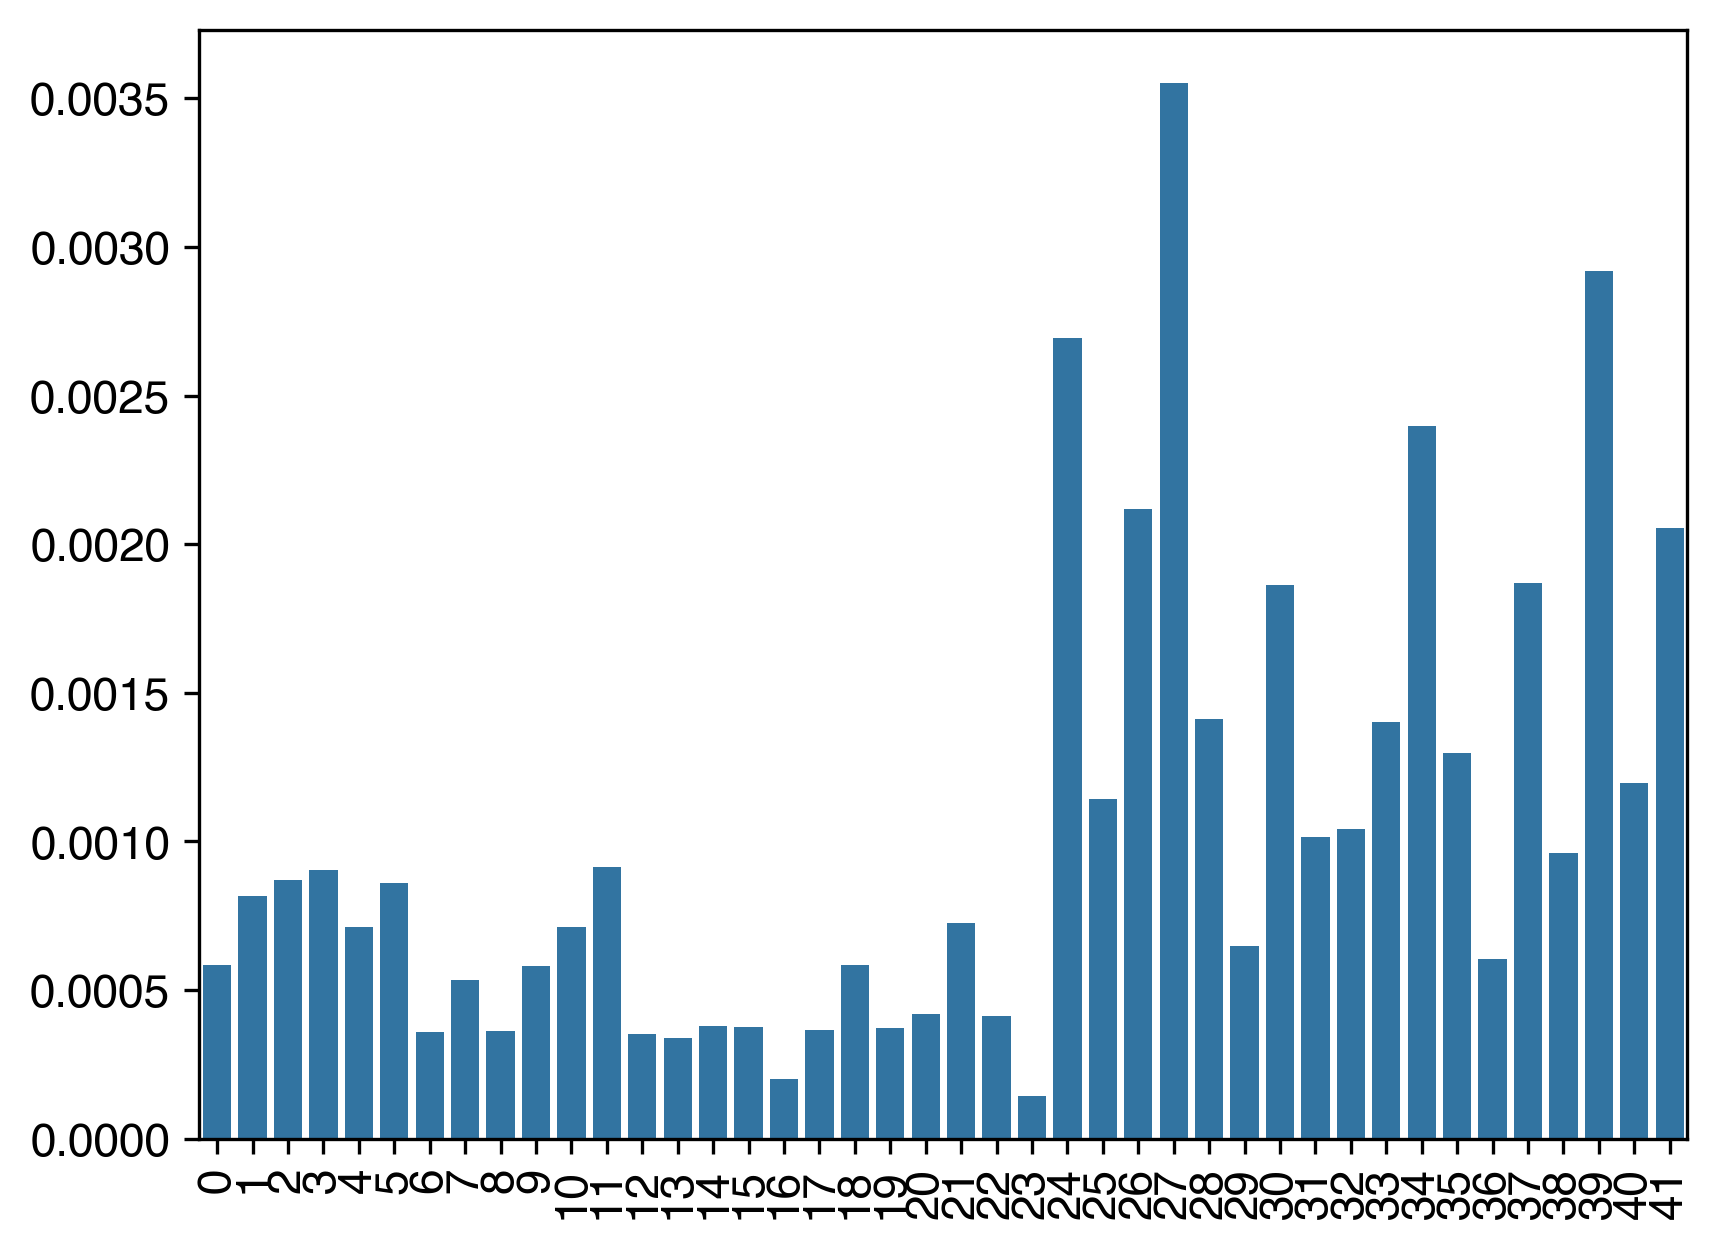

In [20]:
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 

sns.barplot(rmse_v)
plt.xticks(rotation=90)
plt.show()

In [ ]:
import pandapower as pp 
import networkx as nx 
import matplotlib.pyplot as plt 
import numpy as np 
# from utils import custom_se
import copy 
from typing import Tuple 
import pandas as pd 
from itertools import cycle 
import os 
import joblib 
import sys 
import random 
from IPython.display import display 
from ipywidgets import widgets 

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)
print(parent_dir)
from utils.ppnet_utils import use_stored_pfr, custom_se, get_bus_geodata_pos, initialize_network
from utils.gen_utils import dataset_splitter, get_device, load_config

config_tapsegnn = load_config('config.yaml')

net = initialize_network(net_name=config_tapsegnn['data']['net_name'],
                         load_std=config_tapsegnn['data']['load_std'])

num_samples = 64

num_buses = 42

v_label = np.zeros((num_buses, num_samples))
a_label = np.zeros((num_buses, num_samples))
wls_v = np.zeros((num_buses, num_samples))
wls_a = np.zeros((num_buses, num_samples))

pload_ref = net.load.p_mw.values
pload_std_ref = net.load.p_std.values

for iperm in range(num_samples): 
    rng = np.random.default_rng(iperm)
    pload = rng.normal(pload_ref, pload_std_ref)

    # modfify the net data 
    net.load["p_mw"] = pload 

    pp.runpp(net)

    v_label[:, iperm] = net.res_bus.vm_pu.values
    a_label[:, iperm] = net.res_bus.va_degree.values
    p_pfr = net.res_bus.p_mw 
    q_pfr = net.res_bus.q_mvar
    p_pfr_line = net.res_line.p_from_mw

    pfr_dict = {'vm_pfr': net.res_bus.vm_pu.values, 
            'va_pfr': net.res_bus.va_degree.values,
            'p_pfr': p_pfr,
            'q_pfr': q_pfr,
            'p_pfr_line':p_pfr_line}
    
    net_meas = custom_se(net, pfr_dict=pfr_dict, se_iter=20)

    wls_v[:,iperm] = net_meas.res_bus_est.vm_pu.values
    wls_a[:,iperm] = net_meas.res_bus_est.va_degree.values


/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN
Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 



DEBUG:pandapower.estimation.state_estimation:State Estimation successful (10 iterations)
DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)
DEBUG:pandapower.estimation.state_estimation:State Estimation successful (9 iterations)


State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83


DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)
DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)
DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)


State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83


...

State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83


DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)
DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)
DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)


State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83
State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83


DEBUG:pandapower.estimation.state_estimation:State Estimation not successful (10/10 iterations)


State estimation successful for !
Total number of measurements = 84 and number of measurements should be at least 83


In [12]:
# Voltage RMSE for all three networks 
def calc_voltage_rmse(net_meas:pp.pandapowerNet, vm_pfr:np.ndarray, va_pfr:np.ndarray )->Tuple[float,float]:
    """
    Calculate the RMSE of voltage estimates 
    Input: 
        net_meas: pandapower network with measurement datastructure 
    Output: 
        rmse: float, RMSE of voltage estimates 
    """

    rmse_vm_pu = np.sqrt(np.mean((vm_pfr - net_meas.res_bus_est.vm_pu)**2))
    rmse_va_deg = np.sqrt(np.mean((va_pfr - net_meas.res_bus_est.va_degree)**2))
    
    return rmse_vm_pu, rmse_va_deg

rmse_v, rmse_a = calc_voltage_rmse(net_meas=net_meas, vm_pfr=v_label[:, iperm], va_pfr=a_label[:, iperm])
print(f"RMSE V: {rmse_v}, RMSE A: {rmse_a}")

RMSE V: 0.0002854450297597295, RMSE A: 0.0515818787038575


In [2]:
wls_rmse_v = np.sqrt(np.mean((v_label - wls_v)**2, axis=1))
wls_rmse_a = np.sqrt(np.mean((a_label - wls_a)**2, axis=1))

In [3]:
wls_rmse_v

array([0.00021412, 0.00024222, 0.00014763, 0.000207  , 0.00022716,
       0.00027748, 0.00019795, 0.00015851, 0.00010633, 0.00024131,
       0.00017993, 0.00023998, 0.00014121, 0.00020255, 0.00031158,
       0.00025173, 0.00026297, 0.00020055, 0.00028833, 0.00023407,
       0.00019491, 0.00034422, 0.00013715, 0.00019197, 0.00018489,
       0.00021987, 0.00020643, 0.00028102, 0.00028169, 0.00033226,
       0.00031083, 0.00012609, 0.00022714, 0.00019799, 0.0005994 ,
       0.0004312 , 0.00022909, 0.00024316, 0.00025072, 0.00053214,
       0.00026348, 0.00028571])

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.


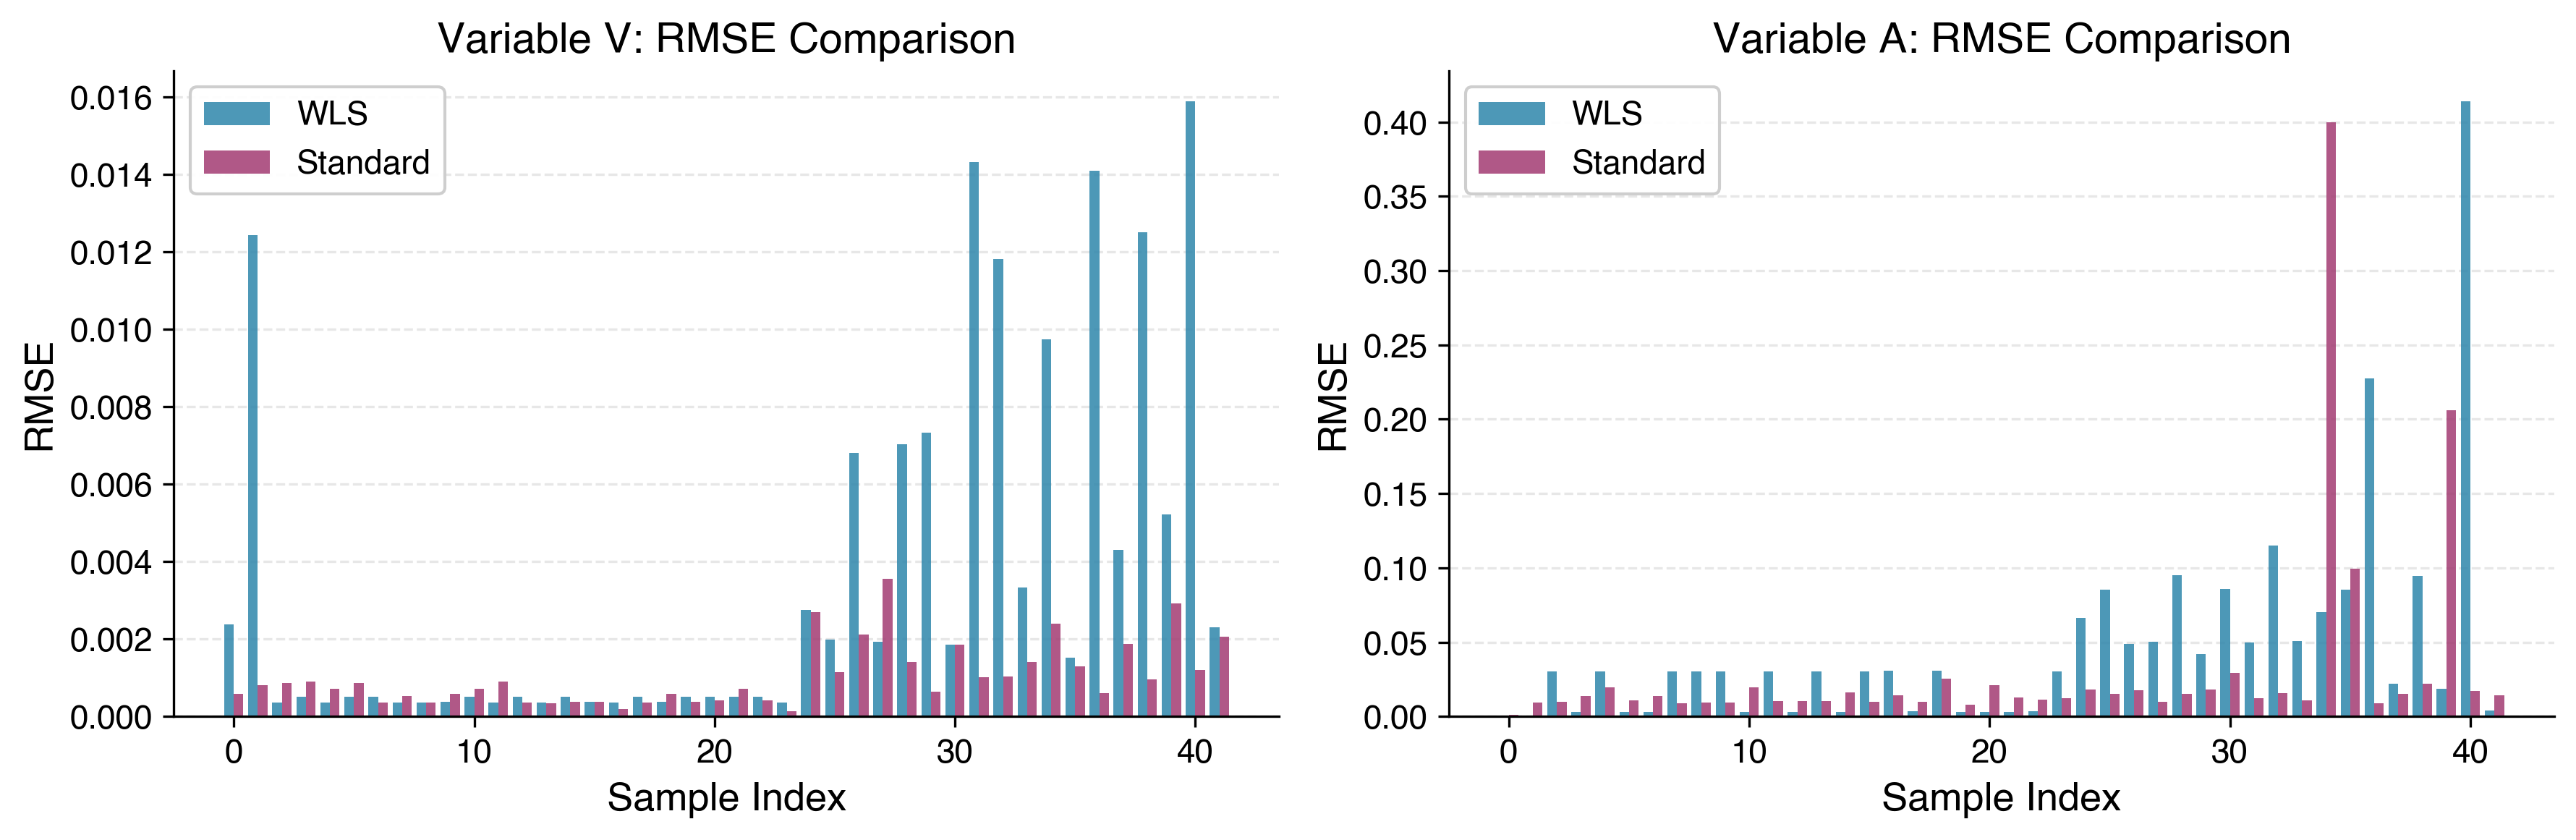

In [38]:
import matplotlib.pyplot as plt 
%matplotlib inline 

# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Variable V comparison
ax1 = axes[0]
x = np.arange(len(wls_rmse_v))
width = 0.4

bars1 = ax1.bar(x - width/2, wls_rmse_v, width, label='WLS', 
                color='#2E86AB', alpha=0.85, edgecolor='none')
bars2 = ax1.bar(x + width/2, rmse_v, width, label='Standard',
                color='#A23B72', alpha=0.85, edgecolor='none')

ax1.set_xlabel('Sample Index', fontweight='semibold')
ax1.set_ylabel('RMSE', fontweight='semibold')
ax1.set_title('Variable V: RMSE Comparison', fontweight='semibold')
ax1.legend(frameon=True, fancybox=True, shadow=False, framealpha=0.95)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

# Plot 2: Variable A comparison
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, wls_rmse_a, width, label='WLS', 
                color='#2E86AB', alpha=0.85, edgecolor='none')
bars4 = ax2.bar(x + width/2, rmse_a, width, label='Standard',
                color='#A23B72', alpha=0.85, edgecolor='none')

ax2.set_xlabel('Sample Index', fontweight='semibold')
ax2.set_ylabel('RMSE', fontweight='semibold')
ax2.set_title('Variable A: RMSE Comparison', fontweight='semibold')
ax2.legend(frameon=True, fancybox=True, shadow=False, framealpha=0.95)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [35]:
from utils.ppnet_utils import  drop_pf_results 

def custom_se_rq4(net: pp.pandapowerNet, 
                  std_meas: float = 0.01, 
                  std_pseudo: float = 0.02,
                  sparsity_prob: float = 0.5, 
                  se_iter: int = 10):
    """
    This function performs custom WLS on Delft Technopolis using the exact locations of available measurements. 
    For other networks, it randomly samples some buses as buses with measurements. 
    
    Bus_type_1: With measurements (in reality for Delft Technopolis)
    Bus_type_2: No measurements (in reality for Delft Technopolis)

    Noise on measurements at bus_type_1: power flow results + std_meas 
    Noise on measurements at bus_type_2: power flow results + std_pseudo

    Args: 
        net (pp.pandapowerNet): Pandapower Network.
        std_meas (float): standard deviation of zero-mean Gaussian noise over the buses. 
        std_pseudo (float): standard deviation of zero-mean Gaussian noise over the buses. 

    Returns: 
        net_meas (pp.pandapowerNet): Net with state-estimation results if converged else original net.

    """

    # drop the measurements or power flow results if any 
    net.measurement.drop(net.measurement.index, inplace = True)
    net = drop_pf_results(net)

    # perform power flow 
    pp.runpp(net, numba=False)

    # for at bus measurements
    vm_pfr = net.res_bus.vm_pu
    p_pfr = net.res_bus.p_mw 
    
    # for to/from bus measurements 
    p_pfr_from_line = net.res_line.p_from_mw
    q_pfr_from_line = net.res_line.q_from_mvar
    p_pfr_to_line = net.res_line.p_to_mw
    q_pfr_to_line = net.res_line.q_to_mvar

    # all bus indices
    all_bus = np.array(net.bus.index)

    if net.name == "Delft 11 Technopolis": 
        
        # v, p measurements available at buses 
        at_bus_meas = np.array([0,1,2,3,5,7,11,17,22])

        # p_flow, q_flow measuremnets available at switching stations to and from the bus 
        flow_bus_meas = np.array([5,7,11,17,22])
        
    else: 
        # consider at and flow buses same for other networks 
        # with some sparsity probability 
        meas_bus_mask = np.random.rand(all_bus.size) >= sparsity_prob 
        at_bus_meas = np.array([bus_id for bus_id in all_bus if meas_bus_mask[bus_id]])

        flow_bus_meas = at_bus_meas 

    # ~at_bus_meas 
    not_at_bus_mask = np.ones(all_bus.size, dtype=bool)
    not_at_bus_mask[at_bus_meas] = False
    not_at_bus_meas = all_bus[not_at_bus_mask]

    not_flow_bus_mask = np.ones(all_bus.size, dtype=bool)
    not_flow_bus_mask[flow_bus_meas] = False 
    not_flow_bus_meas = all_bus[not_flow_bus_mask]

    num_meas = 0
    # create v, p measurements at at_bus_meas 
    for idx, (idx_bus) in enumerate(at_bus_meas):
        num_meas += 2
        vm_at_idx_bus = vm_pfr[idx] + np.random.normal(0, std_meas)
        pmw_at_idx_bus = p_pfr[idx] + np.random.normal(0, std_meas)

        pp.create.create_measurement(net, "v", "bus", value=vm_at_idx_bus, std_dev=std_meas, element = idx_bus)
        pp.create.create_measurement(net, "p", "bus", value=pmw_at_idx_bus, std_dev=std_meas, element = idx_bus)
    
    # create v, p measurements at not_at_bus_meas 
    for idx, (idx_bus) in enumerate(not_at_bus_meas):
        num_meas += 2
        vm_at_idx_bus = vm_pfr[idx] + np.random.normal(0, std_pseudo)
        pmw_at_idx_bus = p_pfr[idx] + np.random.normal(0, std_pseudo)

        pp.create.create_measurement(net, "v", "bus", value=vm_at_idx_bus, std_dev=std_pseudo, element = idx_bus)
        pp.create.create_measurement(net, "p", "bus", value=pmw_at_idx_bus, std_dev=std_pseudo, element = idx_bus)


    # create p_from, q_from, p_to, q_to measurements at flow_bus_meas 
    for iline, line in net.line.iterrows(): 
        from_bus = int(line.from_bus)
        to_bus = int(line.to_bus)

        if to_bus in flow_bus_meas: 
            num_meas += 2
            p_to_mw_meas = p_pfr_to_line[iline] + np.random.normal(0, std_meas)
            q_to_mvar_meas = q_pfr_to_line[iline] + np.random.normal(0, std_meas)
            pp.create.create_measurement(net, "p", "line", value=p_to_mw_meas, std_dev=std_meas, side="to", element=iline)
            pp.create.create_measurement(net, "q", "line", value=q_to_mvar_meas, std_dev=std_meas, side="to", element=iline)

        if from_bus in flow_bus_meas: 
            num_meas += 2
            p_from_mw_meas = p_pfr_from_line[iline] + np.random.normal(0, std_meas)
            q_from_mvar_meas = q_pfr_from_line[iline] + np.random.normal(0, std_meas)
            pp.create.create_measurement(net, "p", "line", value=p_from_mw_meas, std_dev=std_meas, side="from", element=iline)
            pp.create.create_measurement(net, "q", "line", value=q_from_mvar_meas, std_dev=std_meas, side="from", element=iline)

        if to_bus in not_flow_bus_meas:
            num_meas += 2
            p_to_mw_meas = p_pfr_to_line[iline] + np.random.normal(0, std_pseudo)
            q_to_mvar_meas = q_pfr_to_line[iline] + np.random.normal(0, std_pseudo)
            pp.create.create_measurement(net, "p", "line", value=p_to_mw_meas, std_dev=std_pseudo, side="to", element=iline)
            pp.create.create_measurement(net, "q", "line", value=q_to_mvar_meas, std_dev=std_pseudo, side="to", element=iline)

        if from_bus in not_flow_bus_meas: 
            num_meas += 2
            p_from_mw_meas = p_pfr_from_line[iline] + np.random.normal(0, std_pseudo)
            q_from_mvar_meas = q_pfr_from_line[iline] + np.random.normal(0, std_pseudo)
            pp.create.create_measurement(net, "p", "line", value=p_from_mw_meas, std_dev=std_pseudo, side="from", element=iline)
            pp.create.create_measurement(net, "q", "line", value=q_from_mvar_meas, std_dev=std_pseudo, side="from", element=iline)  

    # drop the power flow results 
    net = drop_pf_results(net)

    # number of measurements 
    n_bus = len(net.bus.index)
    n_meas = len(net.bus.index)*2 + len(net.line.index)*4 
    print(f"n_meas = {n_meas}")

    success = pp.estimation.estimate(net, algorithm="wls", init="flat")

    if success: 
        print(f"State estimation successful for {net.name}!")
        # number of measurements 
        print(f"Total number of measurements = {n_meas} and number of measurements should be at least {2*n_bus - 1}")
        
        return net
    elif not success and se_iter > 1:
        # if verbose:
        print(f"State estimation failed. Retrying... Remaining attempts: {se_iter - 1}")
        return custom_se_rq4(net=net, 
                             std_meas=std_meas, 
                             std_pseudo=std_pseudo, 
                             sparsity_prob=sparsity_prob, 
                             se_iter=se_iter - 1) 
    
    else: 
        UserWarning(f"Solver failed for {net.name}, returning net as it is.")
        # number of measurements 
        print(f"Total number of measurements = {n_meas} and number of measurements should be at least {2*n_bus - 1}")
        return net

net_meas = custom_se_rq4(net=net, std_meas=0.01, std_pseudo=0.1, sparsity_prob=0.0, se_iter=10)

DEBUG:pandapower.estimation.state_estimation:State Estimation successful (5 iterations)


n_meas = 172
State estimation successful for !
Total number of measurements = 172 and number of measurements should be at least 83


In [36]:
pp.runpp(net)
vm_pfr = net.res_bus.vm_pu
va_pfr = net.res_bus.va_degree

# calculate RMSE values of state-estimates 
# rmse_mag_v = float(np.sqrt(np.mean((vm_pfr - np.array(net_meas.res_bus_est.vm_pu))**2))) 
# rmse_mag_a = float(np.sqrt(np.mean((va_pfr - np.array(net_meas.res_bus_est.va_degree))**2)))
rmse_mag_v = np.abs(vm_pfr - np.array(net_meas.res_bus_est.vm_pu)) 
rmse_mag_a = np.abs(va_pfr - np.array(net_meas.res_bus_est.va_degree))

In [37]:
rmse_mag_v, rmse_mag_v

wls_rmse_v = rmse_mag_v
wls_rmse_a = rmse_mag_a